In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("data.csv")

In [3]:
df.head()

,Unnamed: 0.1,Unnamed: 0,brand,name,price,spec_rating,processor,CPU,Ram,Ram_type,ROM,ROM_type,GPU,display_size,resolution_width,resolution_height,OS,warranty
0,0,0,HP,Victus 15-fb0157AX Gaming Laptop,49900,73.000000,5th Gen AMD Ryzen 5 5600H,"Hexa Core, 12 Threads",8GB,DDR4,512GB,SSD,4GB AMD Radeon RX 6500M,15.6,1920.0,1080.0,Windows 11 OS,1
1,1,1,HP,15s-fq5007TU Laptop,39900,60.000000,12th Gen Intel Core i3 1215U,"Hexa Core (2P + 4E), 8 Threads",8GB,DDR4,512GB,SSD,Intel UHD Graphics,15.6,1920.0,1080.0,Windows 11 OS,1
2,2,2,Acer,One 14 Z8-415 Laptop,26990,69.323529,11th Gen Intel Core i3 1115G4,"Dual Core, 4 Threads",8GB,DDR4,512GB,SSD,Intel Iris Xe Graphics,14.0,1920.0,1080.0,Windows 11 OS,1
3,3,3,Lenovo,Yoga Slim 6 14IAP8 82WU0095IN Laptop,59729,66.000000,12th Gen Intel Core i5 1240P,"12 Cores (4P + 8E), 16 Threads",16GB,LPDDR5,512GB,SSD,Intel Integrated Iris Xe,14.0,2240.0,1400.0,Windows 11 OS,1
4,4,4,Apple,MacBook Air 2020 MGND3HN Laptop,69990,69.323529,Apple M1,Octa Core (4P + 4E),8GB,DDR4,256GB,SSD,Apple M1 Integrated Graphics,13.3,2560.0,1600.0,Mac OS,1


In [4]:

df.shape

(893, 18)

In [5]:
df.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'brand', 'name', 'price', 'spec_rating',
       'processor', 'CPU', 'Ram', 'Ram_type', 'ROM', 'ROM_type', 'GPU',
       'display_size', 'resolution_width', 'resolution_height', 'OS',
       'warranty'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 893 entries, 0 to 892
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0.1       893 non-null    int64  
 1   Unnamed: 0         893 non-null    int64  
 2   brand              893 non-null    object 
 3   name               893 non-null    object 
 4   price              893 non-null    int64  
 5   spec_rating        893 non-null    float64
 6   processor          893 non-null    object 
 7   CPU                893 non-null    object 
 8   Ram                893 non-null    object 
 9   Ram_type           893 non-null    object 
 10  ROM                893 non-null    object 
 11  ROM_type           893 non-null    object 
 12  GPU                893 non-null    object 
 13  display_size       893 non-null    float64
 14  resolution_width   893 non-null    float64
 15  resolution_height  893 non-null    float64
 16  OS                 893 non

In [7]:
df.isnull().sum()

Unnamed: 0.1         0
Unnamed: 0           0
brand                0
name                 0
price                0
spec_rating          0
processor            0
CPU                  0
Ram                  0
Ram_type             0
ROM                  0
ROM_type             0
GPU                  0
display_size         0
resolution_width     0
resolution_height    0
OS                   0
warranty             0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df["price"].describe()

count       893.000000
mean      79907.409854
std       60880.043823
min        9999.000000
25%       44500.000000
50%       61990.000000
75%       90990.000000
max      450039.000000
Name: price, dtype: float64

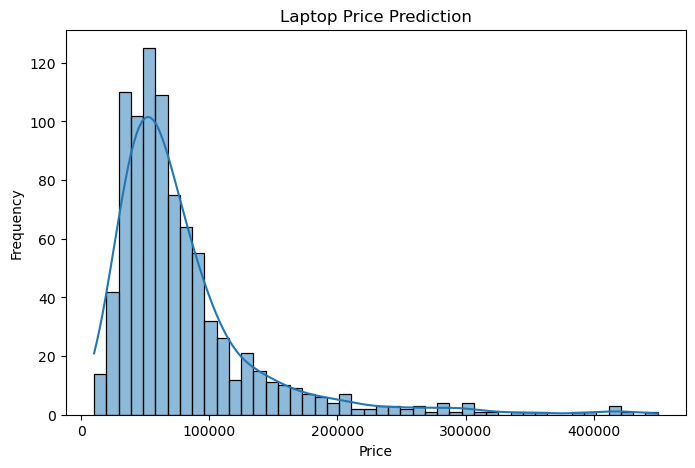

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df["price"], kde=True)
plt.title("Laptop Price Prediction")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [11]:
df.select_dtypes(include="object").columns

Index(['brand', 'name', 'processor', 'CPU', 'Ram', 'Ram_type', 'ROM',
       'ROM_type', 'GPU', 'OS'],
      dtype='object')

In [12]:
df.select_dtypes(include="object").nunique()

brand         30
name         815
processor    184
CPU           29
Ram            7
Ram_type      12
ROM            7
ROM_type       2
GPU          134
OS            14
dtype: int64

In [13]:
df.select_dtypes(exclude = "object").columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'price', 'spec_rating', 'display_size',
       'resolution_width', 'resolution_height', 'warranty'],
      dtype='object')

In [14]:
df[["Unnamed: 0.1", "Unnamed: 0"]].head()

,Unnamed: 0.1,Unnamed: 0
0,0,0
1,1,1
2,2,2
3,3,3
4,4,4


In [15]:
df.drop(columns=["Unnamed: 0.1", "Unnamed: 0"],inplace=True)

In [16]:
df.shape

(893, 16)

In [17]:
# RAM data check and conversion

In [18]:
df["Ram"].unique()

array(['8GB', '16GB', '4GB', '32GB', '2GB', '12GB', '64GB'], dtype=object)

In [19]:
# conversion of ram data, 8GB -> 8

In [20]:
df["Ram"] = df["Ram"].str.replace("GB","").astype(int)

In [21]:
df["Ram"].unique()

array([ 8, 16,  4, 32,  2, 12, 64])

In [22]:
# ROM data checking

In [23]:
df["ROM"].unique()

array(['512GB', '256GB', '128GB', '64GB', '1TB', '32GB', '2TB'],
      dtype=object)

In [24]:
df["ROM"] = df["ROM"].apply(
    lambda x: int(x.replace("GB", "")) if "GB" in x
    else int(x.replace("TB",""))*1024
)

In [25]:
df["ROM"].unique()

array([ 512,  256,  128,   64, 1024,   32, 2048])

In [26]:
# display_size data checking 

In [27]:
df["display_size"].unique()

array([15.6 , 14.  , 13.3 , 14.1 , 11.6 , 16.  , 13.6 , 16.1 , 17.3 ,
       15.3 , 15.56, 13.4 , 13.5 , 18.  , 14.2 , 16.2 , 15.  , 17.  ])

In [28]:
# resolution_width & resolution_height data checking

In [29]:
df[["resolution_width", "resolution_height"]].head()

,resolution_width,resolution_height
0,1920.0,1080.0
1,1920.0,1080.0
2,1920.0,1080.0
3,2240.0,1400.0
4,2560.0,1600.0


In [30]:
# warranty data checking

In [31]:
df["warranty"].unique()

array([1, 0, 2, 3])

In [32]:
df["brand"].unique()

array(['HP', 'Acer', 'Lenovo', 'Apple', 'Dell', 'Asus', 'Samsung',
       'Ultimus', 'Primebook', 'MSI', 'Infinix', 'Wings', 'Honor',
       'Zebronics', 'Xiaomi', 'iBall', 'Chuwi', 'Realme', 'Avita',
       'Walker', 'Huawei', 'Tecno', 'Gigabyte', 'Vaio', 'Microsoft',
       'Fujitsu', 'LG', 'Ninkear', 'Razer', 'AXL'], dtype=object)

In [33]:
# we extract features instead of one hot encoding

In [34]:
df["name"].head(20)

0                      Victus 15-fb0157AX Gaming Laptop
1                                   15s-fq5007TU Laptop
2                                  One 14 Z8-415 Laptop
3                  Yoga Slim 6 14IAP8 82WU0095IN Laptop
4                       MacBook Air 2020 MGND3HN Laptop
5                               Extensa EX214-53 Laptop
6                     Inspiron 3520 D560896WIN9B Laptop
7                   Nitro V ANV15-51 2023 Gaming Laptop
8                    Vivobook 15 X1502ZA-EJ523WS Laptop
9                            Galaxy Book2 Pro 13 Laptop
10                         V15 G3 IAP 82TTA08AIN Laptop
11                          Pro NU14U3INC43BN-CS Laptop
12    TUF Gaming F15 2022 FX507ZC4-HN116W Gaming Laptop
13                                    4G Android Laptop
14                            V15 G4 ‎82YU00W7IN Laptop
15          TUF Gaming F15 FX506HF-HN024W Gaming Laptop
16                          Modern 14 C11M-031IN Laptop
17                                 Zerobook 2023

In [35]:
# checking the gaming laptop and converting them in binary -> gaming = 1, not gaming=0

In [36]:
df["is_gaming"] = df["name"].str.contains("gaming", case=False, na=False).astype(int)

In [37]:
df["is_gaming"].value_counts()

is_gaming
0    656
1    237
Name: count, dtype: int64

In [38]:
# for processor 

In [39]:
df["processor"].head(20)

0          5th Gen AMD Ryzen 5 5600H
1       12th Gen Intel Core i3 1215U
2      11th Gen Intel Core i3 1115G4
3       12th Gen Intel Core i5 1240P
4                           Apple M1
5       12th Gen Intel Core i5 1240P
6       12th Gen Intel Core i3 1215U
7      13th Gen Intel Core i5 13420H
8      12th Gen Intel Core i5 12500H
9       12th Gen Intel Core i5 1240P
10      12th Gen Intel Core i7 1255U
11              Intel Celeron  N4020
12     12th Gen Intel Core i5 12500H
13                  MediaTek MTK8788
14         7th Gen AMD Ryzen 3 7320U
15    11th Gen Intel Core i5 11400H 
16     11th Gen Intel Core i3 1115G4
17     13th Gen Intel Core i9 13900H
18     12th Gen Intel Core i5 12450H
19     11th Gen Intel Core i5 11300H
Name: processor, dtype: object

In [40]:
# extracting features like processor brand, processor family from processor column

In [41]:
df["processor"].unique()[:30]

array(['5th Gen AMD Ryzen 5 5600H', '12th Gen Intel Core i3 1215U',
       '11th Gen Intel Core i3 1115G4', '12th Gen Intel Core i5 1240P',
       'Apple M1', '13th Gen Intel Core i5 13420H',
       '12th Gen Intel Core i5 12500H', '12th Gen Intel Core i7 1255U',
       'Intel Celeron  N4020', 'MediaTek MTK8788',
       '7th Gen AMD Ryzen 3 7320U', '11th Gen Intel Core i5 11400H ',
       '13th Gen Intel Core i9 13900H', '12th Gen Intel Core i5 12450H',
       '11th Gen Intel Core i5 11300H', 'Apple M2',
       '11th Gen Intel Core i5 1135G7 ', '5th Gen AMD Ryzen 7  5800H',
       '5th Gen AMD Ryzen 5 5500U', '3rd Gen AMD Athlon 3050U',
       'Intel Core i3 N305', '13th Gen Intel Core i7 1355U',
       '6th Gen AMD Ryzen 5 6600H', '13th Gen Intel Core i9 13900HX',
       '12th Gen Intel Core i7 12650H', '13th Gen Intel Core i5 1340P',
       '12th Gen Intel Core i5 1235U ', '13th Gen Intel Core i5 13450HX',
       '13th Gen Intel Core i9 13980HX', '11th Gen Intel Core i5 1135G7'],
   

In [42]:
df["processor_brand"] = df["processor"].str.extract(r"(Intel|AMD|Apple|MediaTek)", expand=False)

In [43]:
df["processor_brand"].value_counts()

processor_brand
Intel       609
AMD         255
Apple        12
MediaTek      1
Name: count, dtype: int64

In [44]:
# for Intel

In [45]:
df.loc[df["processor_brand"] == "Intel", "processor"].str.extract(r"(Core i[3-9]|Celeron|Pentium)", expand = False).value_counts()

processor
Core i5    287
Core i7    147
Core i3    105
Core i9     36
Celeron     27
Pentium      3
Name: count, dtype: int64

In [46]:
# for AMD

In [47]:
df.loc[df["processor_brand"]== "AMD", "processor"].str.extract(r"(Ryzen [3-9]|Athlon)", expand=False).value_counts()

processor
Ryzen 5    121
Ryzen 7     85
Ryzen 3     34
Athlon       8
Ryzen 9      7
Name: count, dtype: int64

In [48]:
df["processor_family"] = (df["processor"].str.extract(r"(Core i[3-9]|Celeron|Pentium|Ryzen [3-9]|Athlon)", expand = False))

In [49]:
df["processor_family"].isnull().sum()

np.int64(17)

In [50]:
df.loc[df["processor_family"].isnull(), "processor"].unique()

array(['Apple M1', 'MediaTek MTK8788', 'Apple M2',
       'Intel Atom Quad Core Z3735F', 'Apple M2 Apple M2 Chip',
       'Apple M1 Apple M1 Chip', 'Apple M2 Max M2 Max',
       'Apple M2 Pro M2 Pro', 'Apple M1 Pro M1 Pro',
       'Apple M1 Max M1 Max', 'Intel', 'Intel   N4500',
       '13th Gen Intel 7 13700HX '], dtype=object)

In [51]:
df.loc[df["processor_family"].isnull() & df["processor"].str.contains("Apple M1 Max", na=False),"processor_family"] = "Apple M1 Max"

In [52]:
df.loc[df["processor_family"].isnull() & df["processor"].str.contains("Apple M1 Pro", na=False),"processor_family"] = "Apple M1 Pro"

In [53]:
df.loc[df["processor_family"].isnull() & df["processor"].str.contains("Apple M2 Pro", na=False),"processor_family"] = "Apple M2 Pro"

In [54]:
df.loc[df["processor_family"].isnull() & df["processor"].str.contains("Apple M2 Max", na=False),"processor_family"] = "Apple M2 Max"

In [55]:
df.loc[df["processor_family"].isnull() & df["processor"].str.contains("Apple M1", na=False),"processor_family"] = "Apple M1"

In [56]:
df.loc[df["processor_family"].isnull() & df["processor"].str.contains("Apple M2", na=False),"processor_family"] = "Apple M2"

In [57]:
df["processor_family"].isnull().sum()

np.int64(5)

In [58]:
# checking remaining nan values i.e 5

In [59]:
df.loc[df["processor_family"].isnull(),"processor"].unique()

array(['MediaTek MTK8788', 'Intel Atom Quad Core Z3735F', 'Intel',
       'Intel   N4500', '13th Gen Intel 7 13700HX '], dtype=object)

In [60]:
df.loc[df["processor_family"].isnull() & df["processor"].str.contains("MediaTek", case=False, na=False),"processor_family"] = "MediaTek"

In [61]:
df.loc[df["processor_family"].isnull() & df["processor"].str.contains("Atom", case=False, na=False),"processor_family"] = "Atom"

In [62]:
df.loc[df["processor_family"].isnull() & df["processor"].str.contains("N4500", case=False, na=False),"processor_family"] = "Intel N-Series"

In [63]:
# st.stipr() is used to remove extra spaces

In [64]:
df.loc[df["processor_family"].isnull() & (df["processor"].str.strip() == "Intel"), "processor_family"] = "Intel"

In [65]:
df.loc[df["processor_family"].isnull() & df["processor"].str.contains("Intel 7", case=False, na=False),"processor_family"] = "Intel 7"

In [66]:
df["processor_family"].isnull().sum()    # no missing values , hence feature engineeing done

np.int64(0)

In [67]:
df["processor_family"].value_counts()

processor_family
Core i5           287
Core i7           148
Ryzen 5           128
Core i3           109
Ryzen 7            87
Core i9            36
Ryzen 3            34
Celeron            28
Ryzen 9             8
Athlon              8
Apple M2            4
Apple M1 Pro        3
Pentium             3
Apple M1            2
MediaTek            1
Atom                1
Apple M2 Max        1
Apple M2 Pro        1
Apple M1 Max        1
Intel               1
Intel N-Series      1
Intel 7             1
Name: count, dtype: int64

In [68]:
# feature engineering of GPU

In [69]:
df["GPU"].unique()[:30]

array(['4GB AMD Radeon RX 6500M', 'Intel UHD Graphics',
       'Intel Iris Xe Graphics', 'Intel Integrated Iris Xe',
       'Apple M1 Integrated Graphics', '6GB NVIDIA GeForce RTX 4050',
       'Intel Iris Xe', 'Intel Integrated UHD',
       'Intel Integrated UHD Graphics', '4GB NVIDIA GeForce RTX 3050',
       'ARM Mali G72', 'AMD Radeon Graphics',
       '4GB NVIDIA GeForce RTX 2050', '4GB NVIDIA GeForce GTX 1650',
       'AMD Radeon Vega 7', '8-Core GPU', 'AMD Radeon AMD',
       'AMD Integrated', '8GB NVIDIA GeForce RTX 4070',
       '4GB AMD Radeon RX 6500M Graphics', 'AMD Graphics',
       '8GB NVIDIA GeForce RTX 3070 Ti', 'Intel Integrated Integrated',
       'Intel Graphics', '6GB NVIDIA GeForce RTX 3050',
       'Intel UHD Graphics ', '16GB NVIDIA GeForce RTX 4090',
       'AMD Radeon Radeon Graphics', '8GB NVIDIA GeForce RTX 4060',
       'Intel Integrated Intel UHD Graphics'], dtype=object)

In [70]:
df["gpu_brand"] = df["GPU"].str.extract(r"(NVIDIA|AMD|Intel|Apple|ARM)", expand=False)

In [71]:
df["gpu_brand"].value_counts(dropna=False)

gpu_brand
Intel     398
NVIDIA    297
AMD       173
NaN        22
Apple       2
ARM         1
Name: count, dtype: int64

In [72]:
df.loc[df["gpu_brand"].isnull(),"GPU"].unique()

array(['8-Core GPU', '10-Core GPU', '4GB Radeon Pro 5500M',
       '4GB Nvidia GeForce RTX 2050', '30-core GPU', '19-core GPU',
       '16-core GPU', '32-core GPU', 'Integrated UHD Graphics 620',
       '4GB Geforce MX130', 'Iris Xe Graphics',
       '8GB Nvidia GeForce RTX 4060', '6GB Nvidia GeForce RTX 4050',
       '4GB Nvidia RTX 3050'], dtype=object)

In [73]:
# filling of null values in GPU

In [74]:
df.loc[df["gpu_brand"].isnull() & df["GPU"].str.contains("Nvidia|Geforce|RTX", case=False, na=False), "gpu_brand"]="NVIDIA"

In [75]:
df.loc[df["gpu_brand"].isnull() & df["GPU"].str.contains("Radeon", case=False, na=False), "gpu_brand"]="AMD"

In [76]:
df.loc[df["gpu_brand"].isnull() & df["GPU"].str.contains("Iris|UHD", case=False, na=False), "gpu_brand"]="INTEL"

In [77]:
df["gpu_brand"].isnull().sum()

np.int64(10)

In [78]:
# check the remaining 10 null values

In [79]:
df.loc[df["gpu_brand"].isnull(),"GPU"].unique()

array(['8-Core GPU', '10-Core GPU', '30-core GPU', '19-core GPU',
       '16-core GPU', '32-core GPU'], dtype=object)

In [80]:
df.loc[df["gpu_brand"].isnull(), "gpu_brand"]= "Unknown"

In [81]:
df["gpu_brand"].isnull().sum()

np.int64(0)

In [82]:
# the above null is showing 0 of gpu, it means gpu feature engineering completed

In [83]:
# Creating GPU Memory

In [84]:
df["gpu_memory"] = df["GPU"].str.extract(r"(\d+)GB", expand=False)

In [85]:
df["gpu_memory"].head(20)

0       4
1     NaN
2     NaN
3     NaN
4     NaN
5     NaN
6     NaN
7       6
8     NaN
9     NaN
10    NaN
11    NaN
12      4
13    NaN
14    NaN
15      4
16    NaN
17    NaN
18      4
19      4
Name: gpu_memory, dtype: object

In [86]:
df["gpu_memory"].isnull().sum()

np.int64(576)

In [87]:
# conversion to numeric

In [88]:
df["gpu_memory"] = pd.to_numeric(df["gpu_memory"], errors="coerce")

In [89]:
# fill the NaN value with 0

In [90]:
df["gpu_memory"]= df["gpu_memory"].fillna(0)

In [91]:
df["gpu_memory"].isnull().sum()

np.int64(0)

In [92]:
# OS Checking Time

In [93]:
df["OS"].value_counts()

OS
Windows 11 OS         782
Windows 10 OS          28
DOS OS                 18
Windows 11  OS         15
Mac OS                 12
Windows 10  OS         10
Chrome OS              10
Windows OS              9
Ubuntu OS               2
DOS 3.0 OS              2
Mac 10.15.3\t OS        2
Android 11 OS           1
Mac Catalina OS         1
Mac High Sierra OS      1
Name: count, dtype: int64

In [94]:
df["os_family"] = df["OS"].str.extract(r"(Windows|Mac|Chrome|Ubuntu|Android)", expand=False)

In [95]:
df["os_family"].value_counts(dropna=False)

os_family
Windows    844
NaN         20
Mac         16
Chrome      10
Ubuntu       2
Android      1
Name: count, dtype: int64

In [96]:
df.loc[df["os_family"].isnull() & df["OS"].str.contains("DOS", case=False, na=False), "os_family"]= "DOS"

In [97]:
df["os_family"].isnull().sum()

np.int64(0)

In [98]:
# Feature engineering for CPU

In [99]:
df["CPU"].value_counts()

CPU
Quad Core, 8 Threads               130
Hexa Core, 12 Threads              126
10 Cores (2P + 8E), 12 Threads     125
Octa Core, 16 Threads              102
12 Cores (4P + 8E), 16 Threads      83
Dual Core, 4 Threads                55
14 Cores (6P + 8E), 20 Threads      50
Hexa Core (2P + 4E), 8 Threads      44
Octa Core (4P + 4E), 12 Threads     43
Dual Core, 2 Threads                36
10 Cores (6P + 4E), 16 Threads      26
24 Cores (8P + 16E), 32 Threads     16
16 Cores (8P + 8E), 24 Threads      10
14 Cores (6P + 8E)                   9
5 Cores (1P + 4E), 6 Threads         7
Octa Core (4P + 4E)                  5
Quad Core, 4 Threads                 4
Octa Core, 8 Threads                 4
Octa Core                            3
10 Cores (8P + 2E)                   2
Quad Core                            2
12 Cores                             2
10 Cores, 12 Threads                 2
10 Cores                             2
24 Cores (8P + 16E)                  1
16 Cores, 32 Threads 

In [100]:
# making cpu_cores to handle the cores data 

In [101]:
df["cpu_cores"] = df["CPU"].str.extract(r"(\d+)\s*Core", expand = False)

In [102]:
df["cpu_cores"].value_counts(dropna=True)

cpu_cores
10    157
12     85
14     60
24     17
16     11
5       7
Name: count, dtype: int64

In [103]:
# fill the value for dual core, Quad core, Hexa core, Octa core

In [104]:
df.loc[df["cpu_cores"].isnull() & df["CPU"].str.contains("Dual Core", case = False, na=False), "cpu_cores"]=2

In [105]:
df.loc[df["cpu_cores"].isnull() & df["CPU"].str.contains("Quad Core", case = False, na=False), "cpu_cores"]=4

In [106]:
df.loc[df["cpu_cores"].isnull() & df["CPU"].str.contains("Hexa Core", case = False, na=False), "cpu_cores"]=6

In [107]:
df.loc[df["cpu_cores"].isnull() & df["CPU"].str.contains("Octa Core", case = False, na=False), "cpu_cores"]=8

In [108]:
df["cpu_cores"].isnull().sum()

np.int64(1)

In [109]:
df.loc[df["cpu_cores"].isnull(), "CPU"]

627    20 Threads
Name: CPU, dtype: object

In [110]:
# making cpu threads columns - this will handle the threads data 

In [111]:
df["cpu_threads"] = df["CPU"].str.extract(r"(\d+)\s*Threads", expand=False)

In [112]:
df["cpu_threads"].isnull().sum()

np.int64(26)

In [113]:
df.loc[df["cpu_threads"].isnull(), "CPU"].unique()

array(['Octa Core (4P + 4E)', 'Octa Core', 'Quad Core',
       '14 Cores (6P + 8E)', '12 Cores', '10 Cores (8P + 2E)', '10 Cores',
       '24 Cores (8P + 16E)'], dtype=object)

In [114]:
df[["cpu_cores", "cpu_threads"]].isnull().sum()

cpu_cores       1
cpu_threads    26
dtype: int64

In [115]:
# checking datatype of cpu core and cpu thread, and make conversion to numeric

In [116]:
df[["cpu_cores", "cpu_threads"]].dtypes

cpu_cores      object
cpu_threads    object
dtype: object

In [117]:
df["cpu_cores"]= pd.to_numeric(df["cpu_cores"], errors= "coerce")

In [118]:
df["cpu_threads"] = pd.to_numeric(df["cpu_threads"], errors="coerce")

In [119]:
df[["cpu_cores", "cpu_threads"]].dtypes

cpu_cores      float64
cpu_threads    float64
dtype: object

In [120]:
# we have completed cpu processing and extracted two features-> cpu_cores & cpu_threads , although missing values 1 and 26 respectively handle with median during final preprocessing

In [121]:
# RAM Data Processing

In [122]:
df["Ram_type"].value_counts()

Ram_type
DDR4       499
DDR5       166
LPDDR5     145
LPDDR4X     41
LPDDR4      14
LPDDR4x     13
Unified      7
DDR3         3
LPDDR5X      2
DDR4-        1
LPDDR5x      1
DDR          1
Name: count, dtype: int64

In [123]:
# Normalization of RAM

In [124]:
df["Ram_type"] = df["Ram_type"].replace({"LPDDR4x" : "LPDDR4X"})

In [125]:
df["Ram_type"] = df["Ram_type"].replace({"LDDR5x" : "LPDDR5X"})

In [126]:
df["Ram_type"] = df["Ram_type"].replace({"DDR4-" : "DDR4"})

In [127]:
df["Ram_type"].value_counts()

Ram_type
DDR4       500
DDR5       166
LPDDR5     145
LPDDR4X     54
LPDDR4      14
Unified      7
DDR3         3
LPDDR5X      2
LPDDR5x      1
DDR          1
Name: count, dtype: int64

In [128]:
# ROM Data processing

In [129]:
#ROM_type is already correct , just we do one hot encoding later

In [130]:
df["ROM_type"].value_counts()

ROM_type
SSD          872
Hard-Disk     21
Name: count, dtype: int64

In [131]:
df["ROM"].value_counts()

ROM
512     634
1024    188
256      42
128      12
2048     10
64        5
32        2
Name: count, dtype: int64

In [132]:
# convert TB in GB and also in numeric only like, 512GB -> 512

In [133]:
#df["ROM"] = df["ROM"].apply(lambda x: int(float(x.replace("TB", "")) * 1024)
                           #if "TB" in x
                           #else int(x.replace("GB", ""))
                           #)

In [134]:
df["ROM"].head(20)

0      512
1      512
2      512
3      512
4      256
5      512
6      512
7      512
8      512
9      512
10     512
11     128
12     512
13      64
14     512
15     512
16     512
17    1024
18     512
19     512
Name: ROM, dtype: int64

In [135]:
# checking display_size 

In [136]:
df["display_size"].dtype

dtype('float64')

In [137]:
df["display_size"].isnull().sum()

np.int64(0)

In [138]:
# resolution_width and resolution_height checking

In [139]:
df[["resolution_width", "resolution_height"]].dtypes

resolution_width     float64
resolution_height    float64
dtype: object

In [140]:
df[["resolution_width", "resolution_height"]].isnull().sum()

resolution_width     0
resolution_height    0
dtype: int64

In [141]:
# Warranty checking

In [142]:
df["warranty"].value_counts()

warranty
1    819
2     59
3      9
0      6
Name: count, dtype: int64

In [143]:
df.dtypes

brand                 object
name                  object
price                  int64
spec_rating          float64
processor             object
CPU                   object
Ram                    int64
Ram_type              object
ROM                    int64
ROM_type              object
GPU                   object
display_size         float64
resolution_width     float64
resolution_height    float64
OS                    object
warranty               int64
is_gaming              int64
processor_brand       object
processor_family      object
gpu_brand             object
gpu_memory           float64
os_family             object
cpu_cores            float64
cpu_threads          float64
dtype: object

In [144]:
df.isnull().sum()

brand                 0
name                  0
price                 0
spec_rating           0
processor             0
CPU                   0
Ram                   0
Ram_type              0
ROM                   0
ROM_type              0
GPU                   0
display_size          0
resolution_width      0
resolution_height     0
OS                    0
warranty              0
is_gaming             0
processor_brand      16
processor_family      0
gpu_brand             0
gpu_memory            0
os_family             0
cpu_cores             1
cpu_threads          26
dtype: int64

In [145]:
# handling missing values of processor_ brand

In [146]:
df.loc[df["processor_brand"].isnull(), "processor"].unique()

array(['7th Gen Amd Ryzen 5 7535HS', '11th Gen intel Core i3 1115G4',
       '7th Gen Amd Ryzen 5 7520U', '9th Gen intel Core i7 9750H',
       '7th Gen Amd Ryzen 7 7840H', 'intel Celeron  N4020',
       '7th Gen Amd Ryzen 7 7745HX', '7th Gen Amd Ryzen 5 7530U',
       '7th Gen Amd Ryzen 9 7940HS'], dtype=object)

In [147]:
df.loc[df["processor_brand"].isnull() & df["processor"].str.contains("AMD", case=False, na=False), "processor_brand"] = "AMD"
df.loc[df["processor_brand"].isnull() & df["processor"].str.contains("Intel", case=False, na=False), "processor_brand"] = "Intel"

In [148]:
df["processor_brand"].isnull().sum()

np.int64(0)

In [149]:
df.isnull().sum()

brand                 0
name                  0
price                 0
spec_rating           0
processor             0
CPU                   0
Ram                   0
Ram_type              0
ROM                   0
ROM_type              0
GPU                   0
display_size          0
resolution_width      0
resolution_height     0
OS                    0
warranty              0
is_gaming             0
processor_brand       0
processor_family      0
gpu_brand             0
gpu_memory            0
os_family             0
cpu_cores             1
cpu_threads          26
dtype: int64

In [150]:
# handling the missing values of CPU

In [151]:
df[["cpu_cores", "cpu_threads"]].median()

cpu_cores       8.0
cpu_threads    12.0
dtype: float64

In [152]:
# filling cpu_cores and threads

In [153]:
df["cpu_cores"] = df["cpu_cores"].fillna(8.0)

In [154]:
df["cpu_threads"] = df["cpu_threads"].fillna(12.0)

In [155]:
df[["cpu_cores", "cpu_threads"]].isnull().sum()

cpu_cores      0
cpu_threads    0
dtype: int64

In [156]:
df.isnull().sum()

brand                0
name                 0
price                0
spec_rating          0
processor            0
CPU                  0
Ram                  0
Ram_type             0
ROM                  0
ROM_type             0
GPU                  0
display_size         0
resolution_width     0
resolution_height    0
OS                   0
warranty             0
is_gaming            0
processor_brand      0
processor_family     0
gpu_brand            0
gpu_memory           0
os_family            0
cpu_cores            0
cpu_threads          0
dtype: int64

In [157]:
# Categorical Encoding

In [158]:
df.select_dtypes(include="object").columns

Index(['brand', 'name', 'processor', 'CPU', 'Ram_type', 'ROM_type', 'GPU',
       'OS', 'processor_brand', 'processor_family', 'gpu_brand', 'os_family'],
      dtype='object')

In [159]:
df[["brand","Ram_type","ROM_type","processor_brand","processor_family","gpu_brand","os_family"]].nunique()

brand               30
Ram_type            10
ROM_type             2
processor_brand      4
processor_family    22
gpu_brand            7
os_family            6
dtype: int64

In [160]:
categorical_cols = ["brand","Ram_type","ROM_type","processor_brand","processor_family","gpu_brand","os_family"]

df = pd.get_dummies(df, columns= categorical_cols, drop_first = True, dtype=int)

In [161]:
df.shape

(893, 91)

In [162]:
df = df.drop(columns=["name", "processor", "CPU","GPU","OS"])

In [163]:
df.shape

(893, 86)

In [164]:
df.head(3)

,price,spec_rating,Ram,ROM,display_size,resolution_width,resolution_height,warranty,is_gaming,gpu_memory,...,gpu_brand_Apple,gpu_brand_INTEL,gpu_brand_Intel,gpu_brand_NVIDIA,gpu_brand_Unknown,os_family_Chrome,os_family_DOS,os_family_Mac,os_family_Ubuntu,os_family_Windows
0,49900,73.000000,8,512,15.6,1920.0,1080.0,1,1,4.0,...,0,0,0,0,0,0,0,0,0,1
1,39900,60.000000,8,512,15.6,1920.0,1080.0,1,0,0.0,...,0,0,1,0,0,0,0,0,0,1
2,26990,69.323529,8,512,14.0,1920.0,1080.0,1,0,0.0,...,0,0,1,0,0,0,0,0,0,1


In [165]:
X = df.drop('price',axis=1)
Y = df['price']

In [166]:
X.shape

(893, 85)

In [167]:
Y.shape

(893,)

In [168]:
# Training and Spliting of data

In [169]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2, random_state=42)

In [170]:
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(714, 85)
(179, 85)
(714,)
(179,)


In [171]:
# Linear Regression

In [172]:
from sklearn.linear_model import LinearRegression

In [173]:
model = LinearRegression()
model.fit(X_train, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [174]:
y_pred = model.predict(X_test)

In [175]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [176]:
mae= mean_absolute_error(Y_test,y_pred)
rmse = np.sqrt(mean_squared_error(Y_test, y_pred))
r2 = r2_score(Y_test, y_pred)

In [177]:
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 13737.235631365464
RMSE: 20363.5766806655
R2 Score: 0.8789850407083873


In [178]:
# Random Forest Regression

In [179]:
from sklearn.ensemble import RandomForestRegressor

In [180]:
rf_model = RandomForestRegressor(
    n_estimators = 200,
    random_state= 42
)

In [181]:
rf_model.fit(X_train,Y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [182]:
rf_pred = rf_model.predict(X_test)

In [183]:
rf_mae= mean_absolute_error(Y_test,rf_pred)
rf_rmse = np.sqrt(mean_squared_error(Y_test, rf_pred))
rf_r2 = r2_score(Y_test, rf_pred)

In [184]:
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2 Score:", rf_r2)

MAE: 12429.646943735037
RMSE: 22112.108794695265
R2 Score: 0.8573107473206


In [185]:
#XG Boost

In [186]:
from xgboost import XGBRegressor

In [187]:
xgb_model = XGBRegressor(n_estimators=200, learning_rate= 0.05, max_depth = 6, random_state=42)

In [188]:
xgb_model.fit(X_train,Y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [189]:
xgb_pred = xgb_model.predict(X_test)

In [190]:
xgb_mae= mean_absolute_error(Y_test,xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(Y_test, xgb_pred))
xgb_r2 = r2_score(Y_test, xgb_pred)

In [191]:
print("MAE:", xgb_mae)
print("RMSE:", xgb_rmse)
print("R2 Score:", xgb_r2)

MAE: 12119.7705078125
RMSE: 21521.482476818368
R2 Score: 0.8648315668106079


In [192]:
# saving the xgboost model

In [193]:
import joblib

In [194]:
joblib.dump(xgb_model, "laptop_price_model.pkl")

['laptop_price_model.pkl']

In [195]:
feature_columns = X.columns.tolist()
joblib.dump(feature_columns, "feature_columns.pkl")

['feature_columns.pkl']

In [196]:
# check

In [197]:
import os
print(os.path.exists("laptop_price_model.pkl"))
print(os.path.exists("feature_columns.pkl"))

True
True


In [198]:
# Visualization

In [199]:
# Price distribution

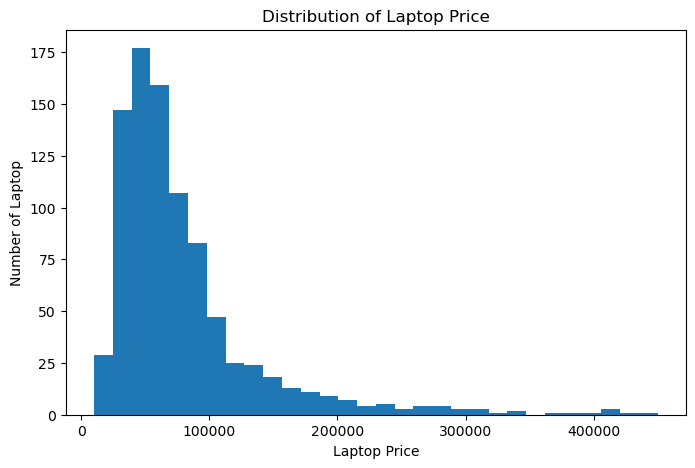

In [200]:
plt.figure(figsize=(8,5))
plt.hist(df['price'],bins=30)
plt.xlabel("Laptop Price")
plt.ylabel("Number of Laptop")
plt.title("Distribution of Laptop Price")
plt.show()

In [201]:
# RAM vs Price

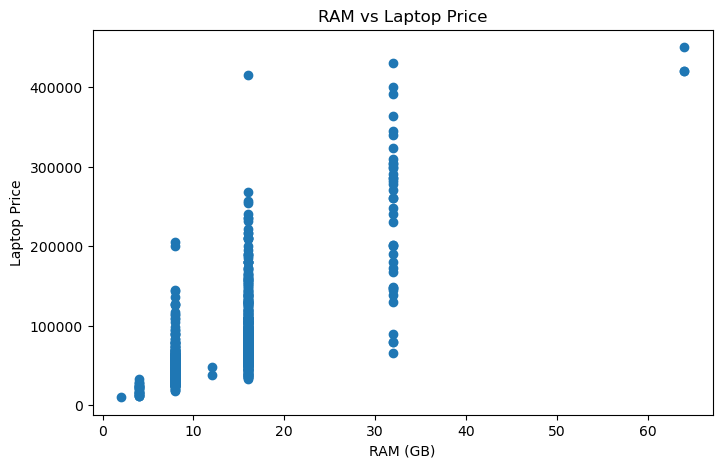

In [202]:
plt.figure(figsize=(8,5))
plt.scatter(df['Ram'],df['price'])
plt.xlabel("RAM (GB)")
plt.ylabel("Laptop Price")
plt.title("RAM vs Laptop Price")
plt.show()

In [203]:
# Spec Rating vs Price

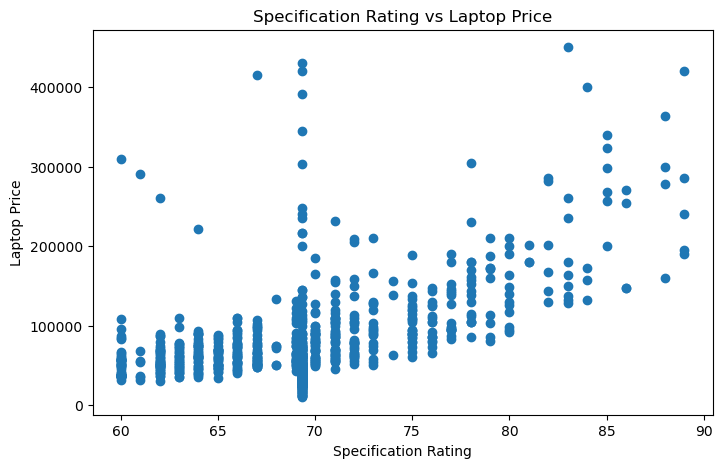

In [204]:
plt.figure(figsize=(8,5))
plt.scatter(df['spec_rating'],df['price'])
plt.xlabel("Specification Rating")
plt.ylabel("Laptop Price")
plt.title("Specification Rating vs Laptop Price")
plt.show()

In [205]:
# ROM vs Laptop Price

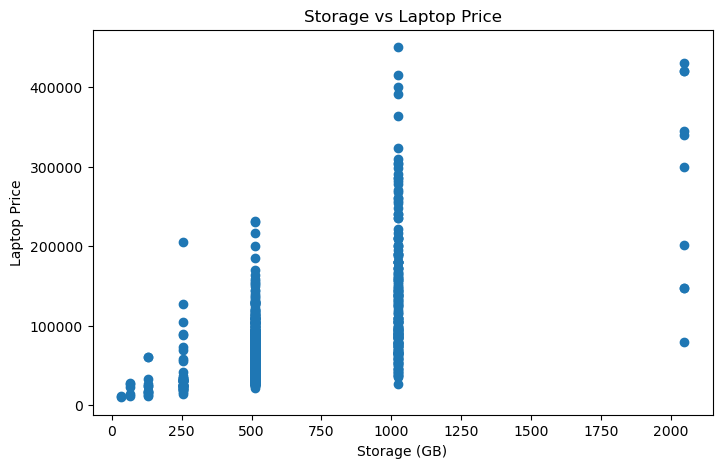

In [206]:
plt.figure(figsize=(8,5))
plt.scatter(df['ROM'],df['price'])
plt.xlabel("Storage (GB)")
plt.ylabel("Laptop Price")
plt.title("Storage vs Laptop Price")
plt.show()

In [207]:
# Gaming vs Average Price

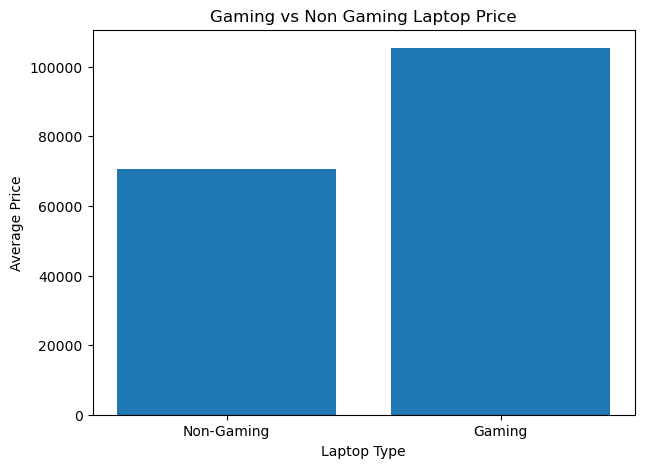

In [208]:
gaming_price = df.groupby('is_gaming')['price'].mean()

plt.figure(figsize=(7,5))
plt.bar(['Non-Gaming','Gaming'], gaming_price)
plt.xlabel("Laptop Type")
plt.ylabel("Average Price")
plt.title("Gaming vs Non Gaming Laptop Price")
plt.show()

In [209]:
# Actual price vs Predicted Price

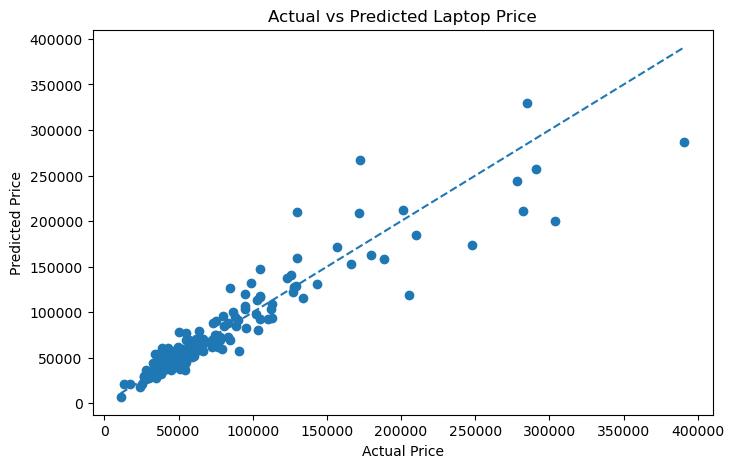

In [210]:
plt.figure(figsize=(8,5))

plt.scatter(Y_test, xgb_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Laptop Price")

plt.plot([Y_test.min(),Y_test.max()],
        [Y_test.min(),Y_test.max()],
        linestyle='--')
plt.show()

In [211]:
# Feature Importance

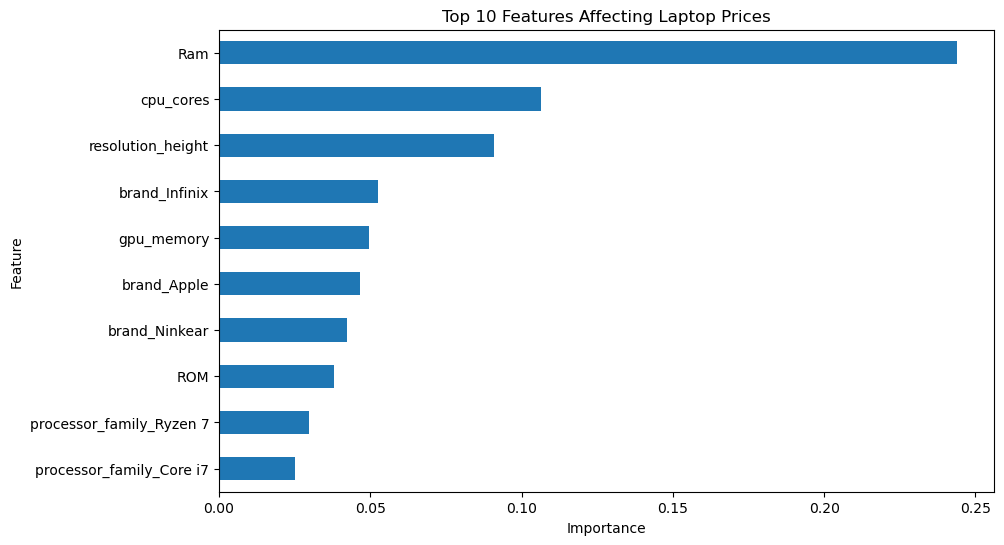

In [212]:
importance = pd.Series(xgb_model.feature_importances_, index = X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
importance.head(10).sort_values().plot(kind="barh")

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title('Top 10 Features Affecting Laptop Prices')
plt.show()

In [213]:
print(X.columns.tolist())

['spec_rating', 'Ram', 'ROM', 'display_size', 'resolution_width', 'resolution_height', 'warranty', 'is_gaming', 'gpu_memory', 'cpu_cores', 'cpu_threads', 'brand_Acer', 'brand_Apple', 'brand_Asus', 'brand_Avita', 'brand_Chuwi', 'brand_Dell', 'brand_Fujitsu', 'brand_Gigabyte', 'brand_HP', 'brand_Honor', 'brand_Huawei', 'brand_Infinix', 'brand_LG', 'brand_Lenovo', 'brand_MSI', 'brand_Microsoft', 'brand_Ninkear', 'brand_Primebook', 'brand_Razer', 'brand_Realme', 'brand_Samsung', 'brand_Tecno', 'brand_Ultimus', 'brand_Vaio', 'brand_Walker', 'brand_Wings', 'brand_Xiaomi', 'brand_Zebronics', 'brand_iBall', 'Ram_type_DDR3', 'Ram_type_DDR4', 'Ram_type_DDR5', 'Ram_type_LPDDR4', 'Ram_type_LPDDR4X', 'Ram_type_LPDDR5', 'Ram_type_LPDDR5X', 'Ram_type_LPDDR5x', 'Ram_type_Unified', 'ROM_type_SSD', 'processor_brand_Apple', 'processor_brand_Intel', 'processor_brand_MediaTek', 'processor_family_Apple M1 Max', 'processor_family_Apple M1 Pro', 'processor_family_Apple M2', 'processor_family_Apple M2 Max', 'p

In [214]:
# Prediction Function Making

In [215]:
import joblib
model = joblib.load("laptop_price_model.pkl")
feature_columns = joblib.load("feature_columns.pkl")

print("Model loaded successfully!")
print("Number of Features:", len(feature_columns))

Model loaded successfully!
Number of Features: 85


In [216]:
# Sample Laptop Feature

In [217]:
sample={
    'spec_rating': 75,
    'Ram': 16,
    'ROM': 512,
    'display_size': 15.6,
    'resolution_width':1920,
    'resolution_height': 1080,
    'warranty': 1,
    'is_gaming':1,
    'gpu_memory':4,
    'cpu_cores':6,
    'cpu_threads':12
}

In [218]:
sample.update({
    'brand':'HP',
    'Ram_type':'DDR5',
    'ROM_type': 'SSD',
    'processor_brand':'Intel',
    'processor_family':'Core i5',
    'gpu_brand':'NVIDIA',
    'os_family':'Windows'
})

In [219]:
# Creating DataFrame

In [220]:
sample_df = pd.DataFrame(0, index=[0], columns=feature_columns)

In [221]:
sample_df['spec_rating'] = sample['spec_rating']
sample_df['Ram'] = sample['Ram']
sample_df['ROM'] = sample['ROM']
sample_df['display_size'] = sample['display_size']
sample_df['resolution_width'] = sample['resolution_width']
sample_df['resolution_height'] = sample['resolution_height']
sample_df['warranty'] = sample['warranty']
sample_df['is_gaming'] = sample['is_gaming']
sample_df['gpu_memory'] = sample['gpu_memory']
sample_df['cpu_cores'] = sample['cpu_cores']
sample_df['cpu_threads'] = sample['cpu_threads']

In [222]:
sample_df['brand_' + sample['brand']] = 1
sample_df['Ram_type_' + sample['Ram_type']] = 1
sample_df['ROM_type_' + sample['ROM_type']] = 1
sample_df['processor_brand_' + sample['processor_brand']] = 1
sample_df['processor_family_' + sample['processor_family']] = 1
sample_df['gpu_brand_' + sample['gpu_brand']] = 1
sample_df['os_family_' + sample['os_family']] = 1

In [223]:
print(sample_df.shape)

(1, 85)


In [224]:
sample_df

,spec_rating,Ram,ROM,display_size,resolution_width,resolution_height,warranty,is_gaming,gpu_memory,cpu_cores,...,gpu_brand_Apple,gpu_brand_INTEL,gpu_brand_Intel,gpu_brand_NVIDIA,gpu_brand_Unknown,os_family_Chrome,os_family_DOS,os_family_Mac,os_family_Ubuntu,os_family_Windows
0,75,16,512,15.6,1920,1080,1,1,4,6,...,0,0,0,1,0,0,0,0,0,1


In [225]:
prediction = model.predict(sample_df)
print(f"Predicted Laptop Price: ₹{prediction[0]:,.2f}")

Predicted Laptop Price: ₹75,452.11


In [226]:
# Create Function for the above task that we have done manually by creating sample & sample_df

In [227]:
def predict_laptop_price(sample):
    
    sample_df = pd.DataFrame(
        0,
        index=[0],
        columns=feature_columns
    )

    # Numerical features
    numerical_features = [
        'spec_rating', 'Ram', 'ROM', 'display_size',
        'resolution_width', 'resolution_height',
        'warranty', 'is_gaming', 'gpu_memory',
        'cpu_cores', 'cpu_threads'
    ]

    for feature in numerical_features:
        sample_df[feature] = sample[feature]

    # Categorical features
    categorical_features = [
        'brand',
        'Ram_type',
        'ROM_type',
        'processor_brand',
        'processor_family',
        'gpu_brand',
        'os_family'
    ]

    for feature in categorical_features:
        column_name = feature + '_' + sample[feature]
        sample_df[column_name] = 1

    prediction = model.predict(sample_df)

    return prediction[0]

In [228]:
price = predict_laptop_price(sample)
print(f"Predicted Laptop Price: ₹{prediction[0]:,.2f}")

Predicted Laptop Price: ₹75,452.11


In [229]:
import tensorflow as tf

In [230]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [231]:
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(714, 85)
(179, 85)
(714,)
(179,)


In [232]:
print(X_train.columns.tolist())

['spec_rating', 'Ram', 'ROM', 'display_size', 'resolution_width', 'resolution_height', 'warranty', 'is_gaming', 'gpu_memory', 'cpu_cores', 'cpu_threads', 'brand_Acer', 'brand_Apple', 'brand_Asus', 'brand_Avita', 'brand_Chuwi', 'brand_Dell', 'brand_Fujitsu', 'brand_Gigabyte', 'brand_HP', 'brand_Honor', 'brand_Huawei', 'brand_Infinix', 'brand_LG', 'brand_Lenovo', 'brand_MSI', 'brand_Microsoft', 'brand_Ninkear', 'brand_Primebook', 'brand_Razer', 'brand_Realme', 'brand_Samsung', 'brand_Tecno', 'brand_Ultimus', 'brand_Vaio', 'brand_Walker', 'brand_Wings', 'brand_Xiaomi', 'brand_Zebronics', 'brand_iBall', 'Ram_type_DDR3', 'Ram_type_DDR4', 'Ram_type_DDR5', 'Ram_type_LPDDR4', 'Ram_type_LPDDR4X', 'Ram_type_LPDDR5', 'Ram_type_LPDDR5X', 'Ram_type_LPDDR5x', 'Ram_type_Unified', 'ROM_type_SSD', 'processor_brand_Apple', 'processor_brand_Intel', 'processor_brand_MediaTek', 'processor_family_Apple M1 Max', 'processor_family_Apple M1 Pro', 'processor_family_Apple M2', 'processor_family_Apple M2 Max', 'p

In [233]:
# ANN Feature Scaling

In [234]:
from sklearn.preprocessing import StandardScaler

In [235]:
scaler_X = StandardScaler()

In [236]:
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

In [237]:
print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:",X_test_scaled.shape)

X_train_scaled: (714, 85)
X_test_scaled: (179, 85)


In [238]:
# Scaling of Price (Target)

In [239]:
scaler_Y = StandardScaler()

In [240]:
Y_train_scaled = scaler_Y.fit_transform(Y_train.values.reshape(-1, 1))
Y_test_scaled = scaler_Y.transform(Y_test.values.reshape(-1,1))

In [241]:
print("Y_train_scaled:", Y_train_scaled.shape)
print("Y_test_scaled:",Y_test_scaled.shape)

Y_train_scaled: (714, 1)
Y_test_scaled: (179, 1)


In [242]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

ann_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),

    Dense(64, activation='relu'),
    Dropout(0.2),

    Dense(32, activation='relu'),

    Dense(1)
])

ann_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

ann_model.summary()

C:\Users\Sheetal\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │          11,008 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 21,377 (83.50 KB)

 Trainable params: 21,377 (83.50 KB)

 Non-trainable params: 0 (0.00 B)

In [243]:
history = ann_model.fit(
    X_train_scaled,
    Y_train_scaled,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.6346 - mae: 0.5366 - val_loss: 0.5064 - val_mae: 0.3621
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3134 - mae: 0.3766 - val_loss: 0.4656 - val_mae: 0.3774
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2784 - mae: 0.3406 - val_loss: 0.3235 - val_mae: 0.2943
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2410 - mae: 0.3143 - val_loss: 0.3038 - val_mae: 0.2964
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2121 - mae: 0.2925 - val_loss: 0.3539 - val_mae: 0.2936
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2476 - mae: 0.3122 - val_loss: 0.2915 - val_mae: 0.2731
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2203 - mae: 0.2921 - val_loss: 0.3327 - val_mae: 0.2794
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1926 - mae: 0.2789 - val_loss: 0.2909 - val_mae: 0.2709
Epoch 9/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0

In [245]:
# ANN predictions on test data
y_pred_scaled = ann_model.predict(X_test_scaled)

# Convert predictions back to original price scale
y_pred = scaler_Y.inverse_transform(y_pred_scaled)

print(y_pred[:5])

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
[[ 81287.555]
 [ 65636.086]
 [ 56747.598]
 [128997.54 ]
 [ 76461.08 ]]


In [246]:
# we apply MAE, RMSE, r2 score to check the predicted is how much close to actual prices

In [248]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(Y_test, y_pred)
rmse = np.sqrt(mean_squared_error(Y_test, y_pred))
r2 = r2_score(Y_test, y_pred)

print("ANN MAE:", mae)
print("ANN RMSE:", rmse)
print("ANN R² Score:", r2)

ANN MAE: 12033.5126953125
ANN RMSE: 23441.07164785774
ANN R² Score: 0.8396437764167786


In [249]:
# using early stopping to improve ann

In [251]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = ann_model.fit(
    X_train_scaled,
    Y_train_scaled,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0398 - mae: 0.1381 - val_loss: 3.2876 - val_mae: 0.3884
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0382 - mae: 0.1307 - val_loss: 2.3381 - val_mae: 0.3583
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0493 - mae: 0.1388 - val_loss: 2.5088 - val_mae: 0.3703
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0420 - mae: 0.1292 - val_loss: 2.0074 - val_mae: 0.3461
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0388 - mae: 0.1372 - val_loss: 2.5364 - val_mae: 0.3776
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0562 - mae: 0.1477 - val_loss: 2.0910 - val_mae: 0.3793
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0495 - mae: 0.1451 - val_loss: 2.1878 - val_mae: 0.3495
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0484 - mae: 0.1377 - val_loss: 1.9700 - val_mae: 0.3543
Epoch 9/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.04

In [253]:
y_pred_scaled = ann_model.predict(X_test_scaled)

y_pred = scaler_Y.inverse_transform(y_pred_scaled)

print(y_pred[:5])

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
[[ 80975.83 ]
 [ 65169.85 ]
 [ 57552.926]
 [124544.68 ]
 [ 76017.27 ]]


In [255]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_ann = mean_absolute_error(Y_test, y_pred)
rmse_ann = np.sqrt(mean_squared_error(Y_test, y_pred))
r2_ann = r2_score(Y_test, y_pred)

print("Improved ANN MAE:", mae_ann)
print("Improved ANN RMSE:", rmse_ann)
print("Improved ANN R² Score:", r2_ann)

Improved ANN MAE: 12757.6845703125
Improved ANN RMSE: 23912.026764789305
Improved ANN R² Score: 0.8331356048583984


In [256]:
# improved ann using early stopping does not improve so much so we use the , previous ann....but early_stopping has replace the previous ann_model so, we have to agin run 100 echoes of prev_ann model. 

In [257]:
ann_model_final = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

ann_model_final.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

ann_model_final.fit(
    X_train_scaled,
    Y_train_scaled,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=0
)

print("ANN training completed successfully!")

C:\Users\Sheetal\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


ANN training completed successfully!


In [258]:
# Now save the ann_model 

In [259]:
ann_model_final.save("laptop_price_ann.keras")

In [261]:
import joblib

joblib.dump(scaler_X, "ann_scaler_X.pkl")
joblib.dump(scaler_Y, "ann_scaler_Y.pkl")

print("ANN model and scalers saved successfully!")

ANN model and scalers saved successfully!


In [262]:
ann_model_final.save("laptop_price_ann.keras")